# [실습 8-1] k-평균 고객 세분화 — 라벨 없는 창고 정리

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 8.2 군집화 |
| 선수 실습 | [실습 7-1] (권장) |
| 준비 | 부록 B.1·B.3 참고 |

아무도 고객에게 유형 라벨을 붙여 준 적이 없다 —
장 도입 질문 그대로, **라벨 없는** 구매 기록에서
k-평균으로 고객 유형을 찾아내고 사람이 해석을 완성한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/<저장소>/ai-intro-labs.git
# %cd ai-intro-labs/notebooks
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch08/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ scikit-learn", sklearn.__version__)

Python 3.12.6
NumPy 2.4.6 / scikit-learn 1.9.0


### [셀 1] 고객 데이터 생성과 탐색 📖

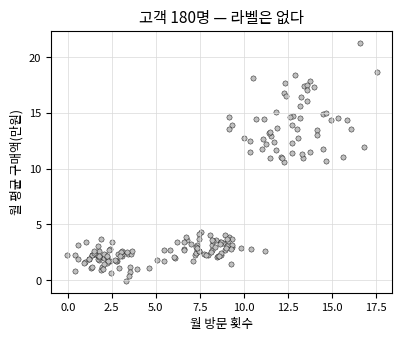

In [2]:
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
# 월 방문 횟수, 월 평균 구매액(만원) — 세 무리 혼합
groups = [rng.normal([8, 3], [1.5, 0.9], (60, 2)),
          rng.normal([13, 14], [1.8, 2.5], (60, 2)),
          rng.normal([2, 2], [0.9, 0.8], (60, 2))]
X_raw = np.vstack(groups)
X = StandardScaler().fit_transform(X_raw)

fig, ax = plt.subplots(figsize=(4.4, 3.4))
ax.scatter(X_raw[:, 0], X_raw[:, 1], s=14,
           color="#bfbfbf", edgecolor="black",
           linewidth=.3)
ax.set_xlabel("월 방문 횟수")
ax.set_ylabel("월 평균 구매액(만원)")
ax.set_title("고객 180명 — 라벨은 없다")
plt.show()

**핵심 포인트**
- 산점도에 색이 **하나뿐**이다 — 정답 라벨이 없는 것이 비지도학습의 출발점(8.1).
- 눈에는 무리가 보이는 것 같다 — 이 직관을 알고리즘으로 바꾸는 것이 군집화다.
- 두 특징의 단위가 다르므로 표준화(`StandardScaler`)했다 — 거리 기반 알고리즘의 기본 예의(7장 정규화 재소환).

### [셀 2] k-평균 반복 과정 4컷 📖

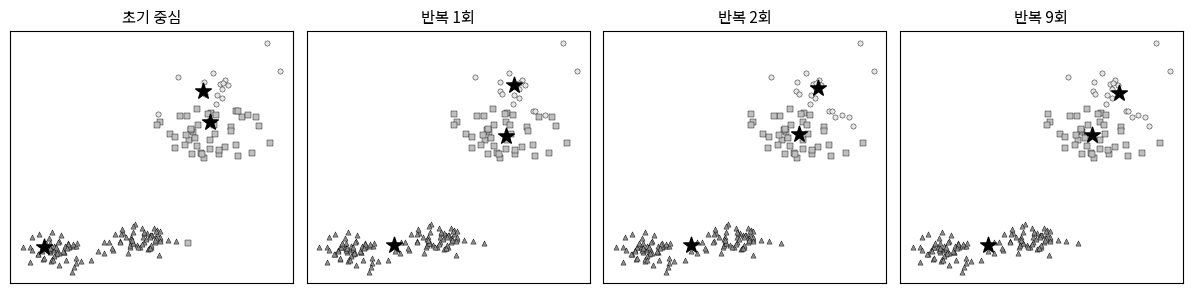

In [3]:
viz.plot_kmeans_steps(X, k=3, seed=1)
plt.show()

**핵심 포인트**
- 4컷의 문법(본문 [그림 8-x]와 동일 구도): 초기 중심(★) → **할당**(가장 가까운 중심으로) → **갱신**(중심을 평균으로 이동) → 수렴.
- 할당과 갱신, 단 두 동작의 반복이 k-평균의 전부다(8.2.1). 함수 본체는 `utils/viz.py`.

실패 시 대처: 마커 모양이 지면과 달라도 군집 **구성**이 같으면 정상이다(군집 번호는 임의적).

### [셀 3] 엘보 방법으로 k 고르기 📖

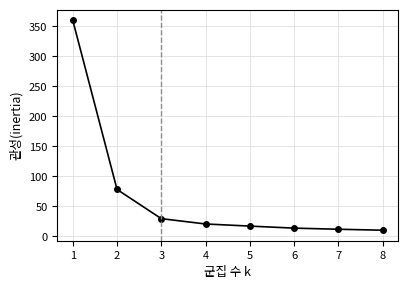

k=2~4 관성: ['78', '30', '21']


In [4]:
from sklearn.cluster import KMeans

ks = range(1, 9)
inertia = [KMeans(k, n_init=10, random_state=42)
           .fit(X).inertia_ for k in ks]

fig, ax = plt.subplots(figsize=(4.4, 3))
ax.plot(list(ks), inertia, "-o", color="black", ms=4)
ax.axvline(3, color="#8c8c8c", ls="--", lw=1)
ax.set_xlabel("군집 수 k")
ax.set_ylabel("관성(inertia)")
plt.show()
print("k=2~4 관성:",
      [f"{v:.0f}" for v in inertia[1:4]])

**핵심 포인트**
- k를 늘리면 관성(군집 내 거리 제곱합)은 항상 줄어든다 — 중요한 것은 **꺾이는 지점**(팔꿈치)이다.
- k=3에서 감소 폭이 급격히 완만해진다 → k=3 채택. 안전한 시작값: 엘보 지점 ±1을 함께 시도해 해석 가능성으로 최종 결정(8.2.1).

실패 시 대처: 엘보가 애매해 보이는 것은 실제 데이터에서 흔한 정상 현상이다 — ±1 탐색 처방을 그대로 쓴다.

### [셀 4] 군집 해석 — 페르소나 명명 훈련 📖

In [5]:
import pandas as pd

km = KMeans(3, n_init=10, random_state=42).fit(X)
df = pd.DataFrame(X_raw, columns=["월 방문", "월 구매액"])
df["군집"] = km.labels_

summary = df.groupby("군집").agg(
    인원=("군집", "size"),
    방문=("월 방문", "mean"),
    구매액=("월 구매액", "mean")).round(1)
print(summary)
# 해석은 사람의 몫: 각 행에 이름을 붙여 보자
# 예) 방문↑구매↑ = "VIP형", 방문↑구매↓ = "알뜰 단골형",
#     방문↓구매↓ = "신규·휴면형"

    인원    방문   구매액
군집                
0   60  12.8  14.1
1   61   2.2   1.9
2   59   8.0   2.9


**핵심 포인트**
- k-평균이 준 것은 **번호뿐**이다 — "VIP형"이라는 의미는 평균 표를 읽은 사람이 완성한다(비지도 결과 해석의 본질, 8.2.3).
- 군집 번호는 실행마다 순서가 바뀔 수 있다 — 숫자가 아니라 **특성 조합**으로 유형을 식별하는 습관을 들이자.

기대 출력: 세 군집의 (방문, 구매액) 평균이 (약 8, 3) / (약 13, 14) / (약 2, 2)로 뚜렷이 갈린다.

### [보조 1] 초기값 민감성 — 다중 시작이 필요한 이유

In [6]:
for seed in range(5):
    km1 = KMeans(3, n_init=1, init="random",
                 random_state=seed).fit(X)
    print(f"시드 {seed}: 관성 {km1.inertia_:.1f}")
print("→ n_init=10(기본값)은 여러 번 시작해"
      " 가장 좋은 결과를 고른다")

시드 0: 관성 69.4
시드 1: 관성 29.6
시드 2: 관성 69.3
시드 3: 관성 29.6
시드 4: 관성 29.6
→ n_init=10(기본값)은 여러 번 시작해 가장 좋은 결과를 고른다


### [보조 2] 계층적 군집화 — 덴드로그램 (8.2.2)

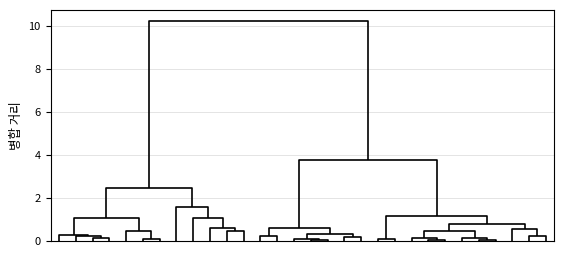

In [7]:
from scipy.cluster.hierarchy import (dendrogram,
                                     linkage)

sample = X[rng.choice(len(X), 30, replace=False)]
fig, ax = plt.subplots(figsize=(6.5, 3))
dendrogram(linkage(sample, "ward"), ax=ax,
           color_threshold=0, above_threshold_color="k")
ax.set_ylabel("병합 거리")
ax.set_xticks([])
plt.show()

### [심화 1] 특징 추가·정규화 유무 실험 (연습문제 심화 직결)

In [8]:
# TODO 1: 표준화 없이(X_raw 그대로) 군집화하면
#         결과가 어떻게 달라지는지 [셀 4]와 비교하자.
km_raw = KMeans(3, n_init=10,
                random_state=42).fit(X_raw)
same = (km_raw.labels_ == km.labels_).mean()
print(f"표준화 유/무 라벨 일치율 {same:.0%} "
      "(순서 차이 포함 — 표로 해석할 것)")

# TODO 2: 세 번째 특징(예: 가입 개월 수)을 만들어
#         추가한 뒤 군집이 어떻게 재편되는지 해석하자.

표준화 유/무 라벨 일치율 100% (순서 차이 포함 — 표로 해석할 것)


---
## 마무리

- k-평균 = 할당·갱신의 반복. 빠르고 단순하지만 k를 사람이 정해야 하고 초기값에 민감하다([보조 1]) — 그래서 엘보 방법과 다중 시작이 표준 절차다.
- 비지도학습의 출력은 라벨이 아니라 **구조**다 — 의미 부여는 사람의 해석([셀 4])이 완성한다.
- 거리 기반 방법에는 표준화가 기본 예의다([심화 1]에서 그 이유를 확인).

**연습문제 연계**: [심화] 특징 추가/정규화 유무 비교·해석은 [심화 1] 뼈대에서 수행한다.

**다음 실습**: [실습 8-2] PCA로 MNIST 시각화 (`ch08/lab-08-02_pca-mnist.ipynb`)